# Parking Spaces Classifier — Podsumowanie Modeli

In [9]:
import pandas as pd

In [10]:
models_data = [
    {
        "name": "YOLOv2n Baseline",
        "architecture": "YOLOv2-nano",
        "notebook": "yolo26n_baseline_description.ipynb",
        "main_diffs": "Pretrenowane wagi (COCO), fine-tuning na PKLot",
        "epochs": 35,
        "map_50_95": 0.86523,
        "map_50": 0.99195,
        "recall": 0.96952,
    },
    {
        "name": "Custom CNN + FasterRCNN (v1)",
        "architecture": "Custom CNN Backbone + Faster R-CNN RPN",
        "notebook": "custom_detector_training1.ipynb",
        "main_diffs": "Autorski backbone: 5 warstw Conv (3→32→64→128→256→512)",
        "epochs": 10,
        "map_50_95": 0.0501,
        "map_50": 0.1340,
        "recall": 0.0913,
    },
    {
        "name": "Custom CNN + FasterRCNN (v1, dłużej)",
        "architecture": "Custom CNN Backbone + Faster R-CNN RPN",
        "notebook": "custom_detector_training2.ipynb",
        "main_diffs": "Ten sam backbone co v1, trening 25 epok zamiast 10",
        "epochs": 25,
        "map_50_95": 0.0495,
        "map_50": 0.1400,
        "recall": 0.0949,
    },
    {
        "name": "UNet-CenterNet (2 głowy)",
        "architecture": "UNet Encoder-Decoder + 2x CenterNet Head",
        "notebook": "custom_detector_training3.ipynb",
        "main_diffs": "Przejście z R-CNN na CenterNet. Głowy: Heatmap + WH. MaxPool downsampling",
        "epochs": 15,
        "map_50_95": 0.4975,
        "map_50": 0.5622,
        "recall": 0.5834,
    },
    {
        "name": "UNet-CenterNet + Offset",
        "architecture": "UNet Encoder-Decoder + 3x CenterNet Head",
        "notebook": "custom_detector_training4.ipynb",
        "main_diffs": "Dodano Offset Head (sub-pikselowa korekcja). Learnable downsampling (stride=2 Conv zamiast MaxPool). Focal Loss + bias init=-2.19",
        "epochs": 25,
        "map_50_95": 0.5890,
        "map_50": 0.6108,
        "recall": 0.6534,
    },
    {
        "name": "AdvancedCenterNet (CoordConv + SE)",
        "architecture": "UNet + CoordConv + SE-Attention Blocks",
        "notebook": "custome_detector_training3.ipynb",
        "main_diffs": "CoordConv (dodatkowe kanały X/Y). Bloki rezydualne z Squeeze-and-Excitation (uwaga na kanałach)",
        "epochs": 25,
        "map_50_95": 0.0920,
        "map_50": 0.1005,
        "recall": 0.1368,
    },
    {
        "name": "Custom detector",
        "architecture": "UNet + Double conv downsampling + CoordConv + SE-Attention + CosineAnnealingLR",
        "notebook": "custom_detector_lightning_training.ipynb",
        "main_diffs": "CosineAnnealingLR scheduler, większy trening",
        "epochs": 20,
        "map_50_95": 0.9638,
        "map_50": 0.9876,
        "recall": 0,
    },
]
df = pd.DataFrame(models_data)

df.style.format({"map_50_95": "{:.4f}", "map_50": "{:.4f}", "recall": "{:.4f}"}).set_properties(
    **{"text-align": "left"}
).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])

,name,architecture,notebook,main_diffs,epochs,map_50_95,map_50,recall
0,YOLOv2n Baseline,YOLOv2-nano,yolo26n_baseline_description.ipynb,"Pretrenowane wagi (COCO), fine-tuning na PKLot",35,0.8652,0.9919,0.9695
1,Custom CNN + FasterRCNN (v1),Custom CNN Backbone + Faster R-CNN RPN,custom_detector_training1.ipynb,Autorski backbone: 5 warstw Conv (3→32→64→128→256→512),10,0.0501,0.1340,0.0913
2,"Custom CNN + FasterRCNN (v1, dłużej)",Custom CNN Backbone + Faster R-CNN RPN,custom_detector_training2.ipynb,"Ten sam backbone co v1, trening 25 epok zamiast 10",25,0.0495,0.1400,0.0949
3,UNet-CenterNet (2 głowy),UNet Encoder-Decoder + 2x CenterNet Head,custom_detector_training3.ipynb,Przejście z R-CNN na CenterNet. Głowy: Heatmap + WH. MaxPool downsampling,15,0.4975,0.5622,0.5834
4,UNet-CenterNet + Offset,UNet Encoder-Decoder + 3x CenterNet Head,custom_detector_training4.ipynb,Dodano Offset Head (sub-pikselowa korekcja). Learnable downsampling (stride=2 Conv zamiast MaxPool). Focal Loss + bias init=-2.19,25,0.5890,0.6108,0.6534
5,AdvancedCenterNet (CoordConv + SE),UNet + CoordConv + SE-Attention Blocks,custome_detector_training3.ipynb,CoordConv (dodatkowe kanały X/Y). Bloki rezydualne z Squeeze-and-Excitation (uwaga na kanałach),25,0.0920,0.1005,0.1368
6,Custom detector,UNet + Double conv downsampling + CoordConv + SE-Attention + CosineAnnealingLR,custom_detector_lightning_training.ipynb,"CosineAnnealingLR scheduler, większy trening",20,0.9638,0.9876,0.0000


In [11]:
models_data = [
    {
        "name": "YOLOv2n Baseline",
        "architecture": "YOLOv2-nano",
        "notebook": "yolo26n_baseline_description.ipynb",
        "main_diffs": "Pretrenowane wagi (COCO), fine-tuning na PKLot",
        "epochs": 35,
        "map_50_95": 0.86523,
        "map_50": 0.99195,
        "recall": 0.96952,
    },
    {
        "name": "Custom detector (SimpleUNetCenterNet)",
        "architecture": "Simple U-Net CenterNet: DoubleConv encoder/decoder + stride-2 downsampling + heatmap/wh/offset heads",
        "notebook": "custom_detector_lightning_training.ipynb",
        "main_diffs": "Learnable downsampling, dodatkowa głowa offsetu i loss CenterNet (focal + L1)",
        "epochs": 20,
        "map_50_95": 0.9638,
        "map_50": 0.9876,
        "recall": 0,
    },
]
df = pd.DataFrame(models_data)

df.style.format({"map_50_95": "{:.4f}", "map_50": "{:.4f}", "recall": "{:.4f}"}).set_properties(
    **{"text-align": "left"}
).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])

,name,architecture,notebook,main_diffs,epochs,map_50_95,map_50,recall
0,YOLOv2n Baseline,YOLOv2-nano,yolo26n_baseline_description.ipynb,"Pretrenowane wagi (COCO), fine-tuning na PKLot",35,0.8652,0.9919,0.9695
1,Custom detector (SimpleUNetCenterNet),Simple U-Net CenterNet: DoubleConv encoder/decoder + stride-2 downsampling + heatmap/wh/offset heads,custom_detector_lightning_training.ipynb,"Learnable downsampling, dodatkowa głowa offsetu i loss CenterNet (focal + L1)",20,0.9638,0.9876,0.0000


In [1]:
import importlib
import sys
from pathlib import Path

import pytorch_lightning as pl
from torch.utils.data import DataLoader

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()),
    Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.models.lit_module as lit_module

importlib.reload(lit_module)
import src.models as models_package

importlib.reload(models_package)

from src.datasets.dataset import PKLotDataset, collate_fn, get_transform
from src.models import load_centernet_checkpoint


def evaluate_best_model():

    ckpt_path = PROJECT_ROOT / "checkpoints/last_ltn.ckpt"

    if not ckpt_path.exists():
        print(f"Brak pliku checkpoint: {ckpt_path}")
        return

    test_dataset = PKLotDataset(
        root_dir=str(PROJECT_ROOT / "data/processed/test"),
        annotation_file=str(PROJECT_ROOT / "data/processed/test/_annotations.coco.json"),
        transforms=get_transform(is_train=False),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn,
    )

    lit_model = load_centernet_checkpoint(ckpt_path)

    trainer = pl.Trainer(accelerator="auto", devices=1)

    print("Rozpoczynam ewaluację na zbiorze testowym...")
    trainer.test(lit_model, dataloaders=test_loader)


evaluate_best_model()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/marcin/Documents/GitHub/parking-spaces-classifier/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) t

Rozpoczynam ewaluację na zbiorze testowym...


/Users/marcin/Documents/GitHub/parking-spaces-classifier/.venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/marcin/Documents/GitHub/parking-spaces-classifier/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test/hm_loss          0.05323176085948944
        test/loss           0.11501601338386536
       test/mAP_50          0.9895153641700745
     test/mAP_50-95         0.9672507643699646
       test/mAP_75          0.9894651770591736
    test/offset_loss       0.025637635961174965
      test/wh_loss          0.3614664375782013
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
import json
from pathlib import Path

import torch

ckpt_path = PROJECT_ROOT / "checkpoints/last_ltn.ckpt"

if not ckpt_path.exists():
    print(f"Brak pliku checkpoint: {ckpt_path}")
else:
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    state_dict = checkpoint.get("state_dict", {}) if isinstance(checkpoint, dict) else {}
    hparams = checkpoint.get("hyper_parameters", {}) if isinstance(checkpoint, dict) else {}

    print(f"Checkpoint: {ckpt_path}")
    print(f"Rozmiar pliku: {ckpt_path.stat().st_size / 1024 / 1024:.2f} MB")
    print(f"Epoch: {checkpoint.get('epoch', 'brak') if isinstance(checkpoint, dict) else 'brak'}")
    print(
        f"Global step: {checkpoint.get('global_step', 'brak') if isinstance(checkpoint, dict) else 'brak'}"
    )
    print(f"Liczba parametrów w state_dict: {len(state_dict)}")
    print(f"Pierwsze klucze: {list(state_dict.keys())[:10]}")
    print("Hiperparametry:")
    print(json.dumps(hparams, indent=2, default=str, ensure_ascii=False))

Checkpoint: /Users/mateusz/iCloud Drive (archiwum)/Documents/apki/parking-spaces-classifier/checkpoints/last_ltn.ckpt
Rozmiar pliku: 25.03 MB
Epoch: 19
Global step: 21740
Liczba parametrów w state_dict: 84
Pierwsze klucze: ['model.inc.conv.0.weight', 'model.inc.conv.1.weight', 'model.inc.conv.1.bias', 'model.inc.conv.1.running_mean', 'model.inc.conv.1.running_var', 'model.inc.conv.1.num_batches_tracked', 'model.inc.conv.3.weight', 'model.inc.conv.4.weight', 'model.inc.conv.4.bias', 'model.inc.conv.4.running_mean']
Hiperparametry:
{
  "lr": 0.0003,
  "epochs": 20,
  "_instantiator": "pytorch_lightning.cli.instantiate_module"
}


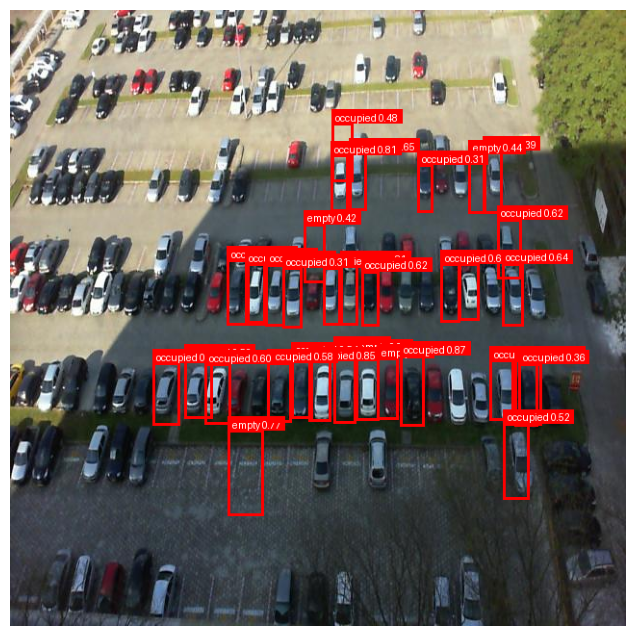

[{'label': 1,
  'label_name': 'empty',
  'score': 0.38524746894836426,
  'box': [491.64520263671875,
   145.7412109375,
   511.03265380859375,
   211.227783203125]},
 {'label': 1,
  'label_name': 'empty',
  'score': 0.4424807131290436,
  'box': [476.4945068359375,
   149.18269856770831,
   494.6689147949219,
   211.92027452256943]},
 {'label': 1,
  'label_name': 'empty',
  'score': 0.4214803874492645,
  'box': [305.2373962402344,
   222.0958794487847,
   327.0687561035156,
   283.80018446180554]},
 {'label': 1,
  'label_name': 'empty',
  'score': 0.38938108086586,
  'box': [336.9331359863281,
   353.3526204427083,
   359.366455078125,
   429.4119466145833]},
 {'label': 1,
  'label_name': 'empty',
  'score': 0.7166528701782227,
  'box': [359.01934814453125,
   356.4939236111111,
   383.3022155761719,
   426.9908311631944]},
 {'label': 1,
  'label_name': 'empty',
  'score': 0.6330653429031372,
  'box': [381.72320556640625,
   361.84233940972223,
   403.0182800292969,
   425.4931640625]},

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw

from src.models.custom_detector import decode_predictions

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = next(
        (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()),
        Path.cwd(),
    )


def infer_and_draw_boxes(model, image_path, threshold=0.3, line_width=3, show=True):
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    original_width, original_height = image.size

    transform = get_transform(is_train=False)
    input_image = transform(image).unsqueeze(0)

    if hasattr(model, "model"):
        model = model.model

    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")

    input_image = input_image.to(device)
    model = model.to(device).eval()

    with torch.no_grad():
        outputs = model(input_image)

    detections = decode_predictions(
        outputs["heatmap"],
        outputs["wh"],
        outputs["offset"],
        threshold=threshold,
    )[0]

    resized_height, resized_width = input_image.shape[-2:]
    scale_x = original_width / resized_width
    scale_y = original_height / resized_height

    draw = ImageDraw.Draw(image)
    class_names = {1: "empty", 2: "occupied"}
    results = []

    for box, score, label in zip(
        detections["boxes"].detach().cpu(),
        detections["scores"].detach().cpu(),
        detections["labels"].detach().cpu(),
    ):
        x1, y1, x2, y2 = box.tolist()
        x1 *= scale_x
        x2 *= scale_x
        y1 *= scale_y
        y2 *= scale_y

        x1 = max(0.0, min(x1, original_width - 1))
        y1 = max(0.0, min(y1, original_height - 1))
        x2 = max(0.0, min(x2, original_width - 1))
        y2 = max(0.0, min(y2, original_height - 1))

        label_id = int(label.item())
        label_name = class_names.get(label_id, f"class_{label_id}")
        caption = f"{label_name} {float(score):.2f}"

        draw.rectangle([x1, y1, x2, y2], outline="red", width=line_width)
        text_bbox = draw.textbbox((x1, y1), caption)
        text_height = text_bbox[3] - text_bbox[1]
        text_y = max(0, y1 - text_height - 4)
        draw.rectangle(
            [x1, text_y, x1 + (text_bbox[2] - text_bbox[0]) + 8, text_y + text_height + 4],
            fill="red",
        )
        draw.text((x1 + 4, text_y + 2), caption, fill="white")

        results.append(
            {
                "label": label_id,
                "label_name": label_name,
                "score": float(score),
                "box": [x1, y1, x2, y2],
            }
        )

    if show:
        plt.figure(figsize=(14, 8))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

    return image, results


model = load_centernet_checkpoint(PROJECT_ROOT / "checkpoints/last_ltn.ckpt")
annotated_image, detections = infer_and_draw_boxes(
    model,
    PROJECT_ROOT / "data/raw/test/2012-09-11_15_53_00_jpg.rf.8282544a640a23df05bd245a9210e663.jpg",
)
detections